<a href="https://colab.research.google.com/github/PritsP/Quant-Project/blob/main/notebooks/bsm_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

In [ ]:
def bsm_call_price(S, K, T, r, sigma):
    """
    Black-Scholes-Merton price of a European call option.

    S     : current stock price
    K     : strike price
    T     : time to expiry, in years
    r     : risk-free rate (annualized, e.g. 0.05 for 5%)
    sigma : volatility (annualized, e.g. 0.20 for 20%)
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return price


def bsm_put_price(S, K, T, r, sigma):
    """
    Black-Scholes-Merton price of a European put option.
    Derived via put-call parity rather than rewriting from scratch:
    P = C - S + K*e^(-rT)
    """
    call = bsm_call_price(S, K, T, r, sigma)
    price = call - S + K * np.exp(-r * T)
    return price

    # A 3-month ATM call on a $100 stock, 5% rates, 20% vol
test_call = bsm_call_price(S=100, K=100, T=0.25, r=0.05, sigma=0.20)
test_put  = bsm_put_price(S=100, K=100, T=0.25, r=0.05, sigma=0.20)

print(f"Call price: {test_call:.4f}")
print(f"Put price:  {test_put:.4f}")

Call price: 4.6150
Put price:  3.3728


In [ ]:
def delta(S, K, T, r, sigma, option_type='call'):
    """Rate of change of option price with respect to a $1 move in S."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    if option_type == 'call':
        return norm.cdf(d1)
    elif option_type == 'put':
        return norm.cdf(d1) - 1


def gamma(S, K, T, r, sigma):
    """Rate of change of delta with respect to a $1 move in S. Same for calls and puts."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))


def vega(S, K, T, r, sigma):
    """Rate of change of option price per 1.0 (100%) change in vol.
    Convention: many traders quote this per 1% vol move, so divide by 100 if needed."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)


def theta(S, K, T, r, sigma, option_type='call'):
    """Rate of change of option price per day passing. Returned as annualized;
    divide by 365 for the daily figure traders actually look at."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    term1 = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))

    if option_type == 'call':
        term2 = -r * K * np.exp(-r * T) * norm.cdf(d2)
        return term1 + term2
    elif option_type == 'put':
        term2 = r * K * np.exp(-r * T) * norm.cdf(-d2)
        return term1 + term2


def rho(S, K, T, r, sigma, option_type='call'):
    """Rate of change of option price per 1.0 (100%) change in interest rate."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        return K * T * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        return -K * T * np.exp(-r * T) * norm.cdf(-d2)

print(f"Delta: {delta(100, 100, 0.25, 0.05, 0.20, 'call'):.4f}")
print(f"Gamma: {gamma(100, 100, 0.25, 0.05, 0.20):.4f}")
print(f"Vega:  {vega(100, 100, 0.25, 0.05, 0.20):.4f}")
print(f"Theta: {theta(100, 100, 0.25, 0.05, 0.20, 'call') / 365:.4f}  (daily)")

Delta: 0.5695
Gamma: 0.0393
Vega:  19.6440
Theta: -0.0287  (daily)


In [ ]:
def implied_vol(market_price, S, K, T, r, option_type='call',
                 initial_guess=0.20, max_iterations=100, tolerance=1e-6):
    """
    Solves for the implied volatility that makes the BSM price
    equal to the observed market price.

    Uses Newton-Raphson first; falls back to Brent's method if
    Newton-Raphson fails to converge or vega is too small.
    """
    sigma = initial_guess

    # --- Attempt 1: Newton-Raphson ---
    for i in range(max_iterations):
        if option_type == 'call':
            price = bsm_call_price(S, K, T, r, sigma)
        else:
            price = bsm_put_price(S, K, T, r, sigma)

        diff = price - market_price

        if abs(diff) < tolerance:
            return sigma  # converged

        v = vega(S, K, T, r, sigma)

        if v < 1e-8:
            break  # vega too small — Newton-Raphson will be unstable here

        sigma = sigma - diff / v

        if sigma <= 0 or sigma > 5:
            break  # sigma went somewhere nonsensical, abandon and fall back

    # --- Attempt 2: Brent's method (fallback) ---
    def objective(s):
        if option_type == 'call':
            return bsm_call_price(S, K, T, r, s) - market_price
        else:
            return bsm_put_price(S, K, T, r, s) - market_price

    try:
        return brentq(objective, 1e-6, 5.0, xtol=tolerance)
    except ValueError:
        # Brent's method needs the objective to have opposite signs at the
        # two endpoints — if it doesn't, no solution exists in that range
        return np.nan

 # Generate a price with a known vol, then solve backwards and confirm we recover it
true_sigma = 0.25
synthetic_price = bsm_call_price(S=100, K=105, T=0.5, r=0.05, sigma=true_sigma)

recovered_sigma = implied_vol(synthetic_price, S=100, K=105, T=0.5, r=0.05, option_type='call')

print(f"True vol:      {true_sigma:.4f}")
print(f"Recovered vol: {recovered_sigma:.4f}")

True vol:      0.2500
Recovered vol: 0.2500


In [ ]:
# Deep OTM option — vega is tiny here, this tests your fallback
deep_otm_price = bsm_call_price(S=100, K=200, T=0.1, r=0.05, sigma=0.20)
iv_deep_otm = implied_vol(deep_otm_price, S=100, K=200, T=0.1, r=0.05, option_type='call')
print(f"Deep OTM recovered vol: {iv_deep_otm:.4f}")

# Near-zero time to expiry
near_expiry_price = bsm_call_price(S=100, K=100, T=0.001, r=0.05, sigma=0.20)
iv_near_expiry = implied_vol(near_expiry_price, S=100, K=100, T=0.001, r=0.05, option_type='call')
print(f"Near-expiry recovered vol: {iv_near_expiry:.4f}")


Deep OTM recovered vol: 0.2000
Near-expiry recovered vol: 0.2000


In [ ]:
# ============================================================
# -- upload, clean, compute IV, validate
# ============================================================

from google.colab import files
import pandas as pd
import numpy as np
import io
from datetime import datetime
from scipy.stats import norm
from scipy.optimize import brentq

# ---- BSM FUNCTIONS ----

def bsm_call_price(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bsm_put_price(S, K, T, r, sigma):
    call = bsm_call_price(S, K, T, r, sigma)
    return call - S + K * np.exp(-r * T)

def vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def implied_vol(market_price, S, K, T, r, option_type='call',
                initial_guess=0.20, max_iterations=100, tolerance=1e-6):
    sigma = initial_guess
    for i in range(max_iterations):
        if option_type == 'call':
            price = bsm_call_price(S, K, T, r, sigma)
        else:
            price = bsm_put_price(S, K, T, r, sigma)
        diff = price - market_price
        if abs(diff) < tolerance:
            return sigma
        v = vega(S, K, T, r, sigma)
        if v < 1e-8:
            break
        sigma = sigma - diff / v
        if sigma <= 0 or sigma > 5:
            break
    # Brent's fallback
    def objective(s):
        if option_type == 'call':
            return bsm_call_price(S, K, T, r, s) - market_price
        else:
            return bsm_put_price(S, K, T, r, s) - market_price
    try:
        return brentq(objective, 1e-6, 5.0, xtol=tolerance)
    except:
        return np.nan

# ---- UPLOAD AND LOAD ----

uploaded = files.upload()
filename = list(uploaded.keys())[0]
content = uploaded[filename].decode('utf-8')
df_raw = pd.read_csv(io.StringIO(content), skiprows=3)
print(f"Loaded {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

# ---- MARKET INPUTS ----

S = 747.41   # SPY spot price from file header
r = 0.053    # 3-month Treasury yield, annualized
today = datetime.today()

# ---- COMPUTE T (time to expiry in years) ----

df_raw['Expiry_dt'] = pd.to_datetime(df_raw['Expiration Date'])
df_raw['T'] = (df_raw['Expiry_dt'] - today).dt.days / 365

# ---- SPLIT CALLS AND PUTS ----

calls = df_raw[[
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Calls', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV', 'Delta', 'Gamma', 'Open Interest'
]].copy()
calls.columns = [
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Contract', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV_cboe', 'Delta_cboe', 'Gamma_cboe', 'Open Interest'
]
calls['option_type'] = 'call'

puts = df_raw[[
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Puts', 'Last Sale.1', 'Net.1', 'Bid.1', 'Ask.1', 'Volume.1',
    'IV.1', 'Delta.1', 'Gamma.1', 'Open Interest.1'
]].copy()
puts.columns = [
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Contract', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV_cboe', 'Delta_cboe', 'Gamma_cboe', 'Open Interest'
]
puts['option_type'] = 'put'

options = pd.concat([calls, puts], ignore_index=True)
print(f"Total options before cleaning: {len(options)} ({len(calls)} calls, {len(puts)} puts)")

# ---- DATA CLEANING ----

options['Mid'] = (options['Bid'] + options['Ask']) / 2
options['Moneyness'] = options['Strike'] / S

n = len(options)
options = options[options['Volume'] > 0]
print(f"After zero volume filter:      {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['Open Interest'] > 10]
print(f"After low open interest filter:{len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['Bid'] > 0]
print(f"After zero bid filter:         {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['T'] > 7/365]
print(f"After short dated filter:      {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[(options['Moneyness'] >= 0.80) & (options['Moneyness'] <= 1.20)]
print(f"After deep ITM/OTM filter:     {len(options)} (removed {n - len(options)})")

options = options.reset_index(drop=True)
print(f"\nFinal clean dataset: {len(options)} options")

# ---- COMPUTE IMPLIED VOL ----

def compute_iv_row(row):
    try:
        return implied_vol(
            market_price = row['Mid'],
            S            = S,
            K            = row['Strike'],
            T            = row['T'],
            r            = r,
            option_type  = row['option_type']
        )
    except:
        return np.nan

options['IV_computed'] = options.apply(compute_iv_row, axis=1)

n_before = len(options)
options = options.dropna(subset=['IV_computed'])
print(f"IV computed successfully for {len(options)}/{n_before} options")

# ---- VALIDATE AGAINST CBOE ----

options['IV_diff'] = options['IV_computed'] - options['IV_cboe']
options['IV_diff_pct'] = (options['IV_diff'] / options['IV_cboe']) * 100

print("\nIV Comparison — Your Solver vs CBOE:")
print(options[[
    'Expiration Date', 'Strike', 'option_type',
    'Mid', 'IV_cboe', 'IV_computed', 'IV_diff_pct'
]].to_string())

print(f"\nMean absolute difference: {options['IV_diff'].abs().mean():.6f}")
print(f"Max absolute difference:  {options['IV_diff'].abs().max():.6f}")

Saving spy_quotedata.csv to spy_quotedata (1).csv
Loaded 12 rows, 22 columns
Total options before cleaning: 24 (12 calls, 12 puts)
After zero volume filter:      23 (removed 1)
After low open interest filter:23 (removed 0)
After zero bid filter:         23 (removed 0)
After short dated filter:      23 (removed 0)
After deep ITM/OTM filter:     23 (removed 0)

Final clean dataset: 23 options
IV computed successfully for 23/23 options

IV Comparison — Your Solver vs CBOE:
    Expiration Date  Strike option_type     Mid  IV_cboe  IV_computed  IV_diff_pct
0   Fri Aug 21 2026   745.0        call  23.495   0.1505     0.159546     6.010625
1   Fri Aug 21 2026   746.0        call  22.825   0.1496     0.158529     5.968367
2   Fri Aug 21 2026   747.0        call  22.010   0.1474     0.156210     5.976810
3   Fri Aug 21 2026   748.0        call  21.360   0.1465     0.155241     5.966292
4   Fri Aug 21 2026   749.0        call  20.825   0.1440     0.155182     7.765035
5   Fri Aug 21 2026   750.0

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import io
from datetime import datetime
from scipy.stats import norm
from scipy.optimize import brentq

# ---- UPLOAD ALL 5 FILES AT ONCE ----
# When the picker opens, select all 5 CSVs at the same time
# (hold Cmd on Mac to select multiple files)

uploaded = files.upload()

# ---- LOAD AND COMBINE ----

S = 744.78  # update this to whatever SPY's current price shows on CBOE today
r = 0.053
today = datetime.today()

all_dfs = []

for filename, content in uploaded.items():
    print(f"Loading {filename}...")

    # Same loading logic as before
    text = content.decode('utf-8')
    df = pd.read_csv(io.StringIO(text), skiprows=3)

    # Add a column so we know which file each row came from
    df['source_file'] = filename
    all_dfs.append(df)

# Stack all files into one DataFrame
df_raw = pd.concat(all_dfs, ignore_index=True)

print(f"\nTotal rows across all files: {len(df_raw)}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nUnique expiry dates found:")
print(df_raw['Expiration Date'].value_counts().sort_index())

Saving spy_quotedata august.csv to spy_quotedata august (1).csv
Saving spy_quotedata december.csv to spy_quotedata december (1).csv
Saving spy_quotedata july.csv to spy_quotedata july (1).csv
Saving spy_quotedata october.csv to spy_quotedata october (1).csv
Saving spy_quotedata september.csv to spy_quotedata september (1).csv
Loading spy_quotedata august (1).csv...
Loading spy_quotedata december (1).csv...
Loading spy_quotedata july (1).csv...
Loading spy_quotedata october (1).csv...
Loading spy_quotedata september (1).csv...

Total rows across all files: 480
Columns: ['Expiration Date', 'Calls', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume', 'IV', 'Delta', 'Gamma', 'Open Interest', 'Strike', 'Puts', 'Last Sale.1', 'Net.1', 'Bid.1', 'Ask.1', 'Volume.1', 'IV.1', 'Delta.1', 'Gamma.1', 'Open Interest.1', 'source_file']

Unique expiry dates found:
Expiration Date
Fri Aug 07 2026    20
Fri Aug 14 2026    20
Fri Aug 21 2026    20
Fri Dec 18 2026    20
Fri Jul 10 2026    20
Fri Jul 17 2026    20

Rows after expiry filter: 120
Expiration Date
Fri Aug 21 2026    20
Fri Dec 18 2026    20
Fri Jul 17 2026    20
Fri Oct 16 2026    20
Fri Sep 18 2026    20
Thu Jul 02 2026    20
Name: count, dtype: int64

Total options before cleaning: 240
After zero volume filter:       234 (removed 6)
After low open interest filter: 233 (removed 1)
After zero bid filter:          217 (removed 16)
After short dated filter:       194 (removed 23)
After deep ITM/OTM filter:      194 (removed 0)

Final clean dataset: 194 options
IV computed for 194 options

Options per expiry:
Expiration Date
Fri Aug 21 2026    40
Fri Dec 18 2026    38
Fri Jul 17 2026    40
Fri Oct 16 2026    37
Fri Sep 18 2026    39
Name: IV_computed, dtype: int64


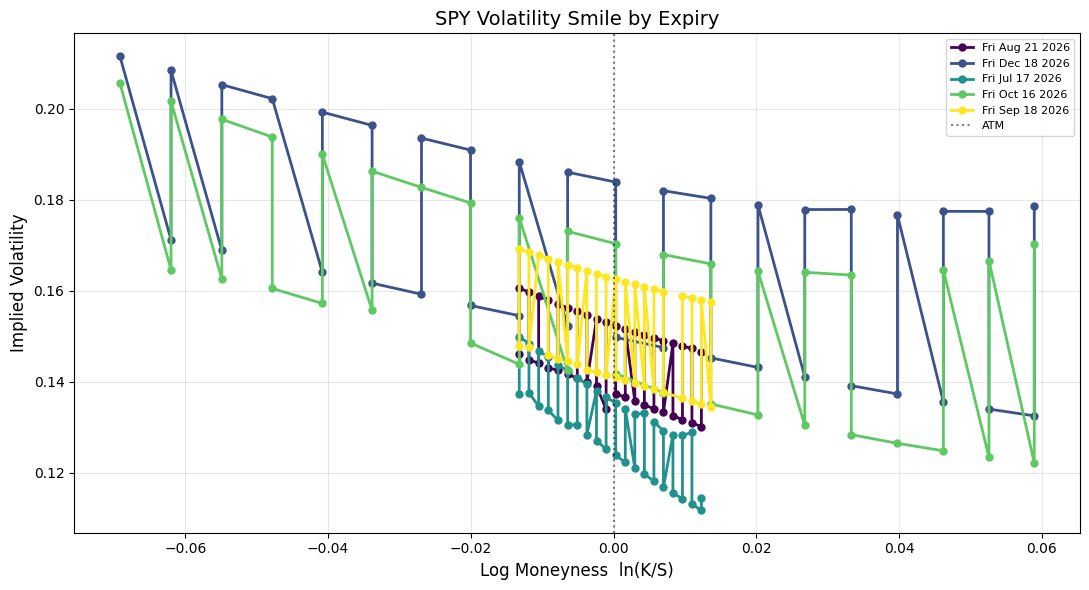

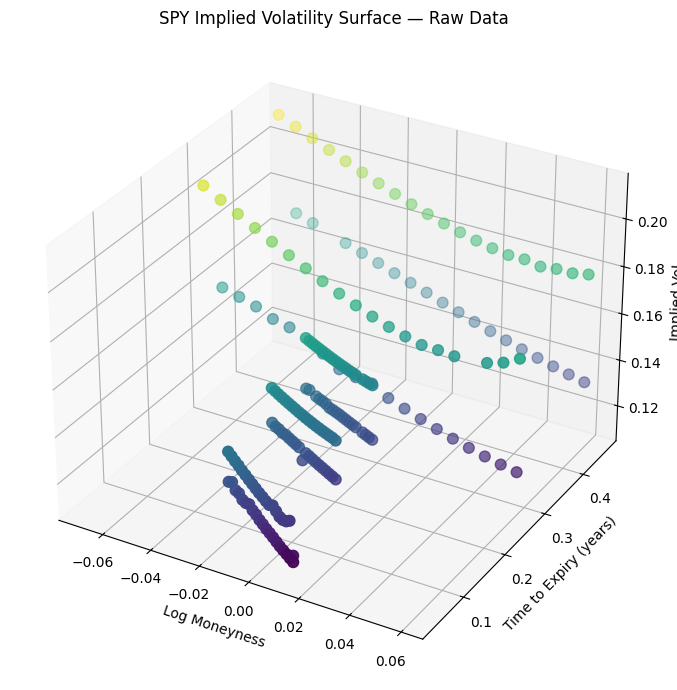

Fitting smoothing splines...
  T=0.036 yrs — smoothing spline on 20 points
  T=0.132 yrs — smoothing spline on 20 points
  T=0.208 yrs — smoothing spline on 20 points
  T=0.285 yrs — smoothing spline on 20 points
  T=0.458 yrs — smoothing spline on 20 points


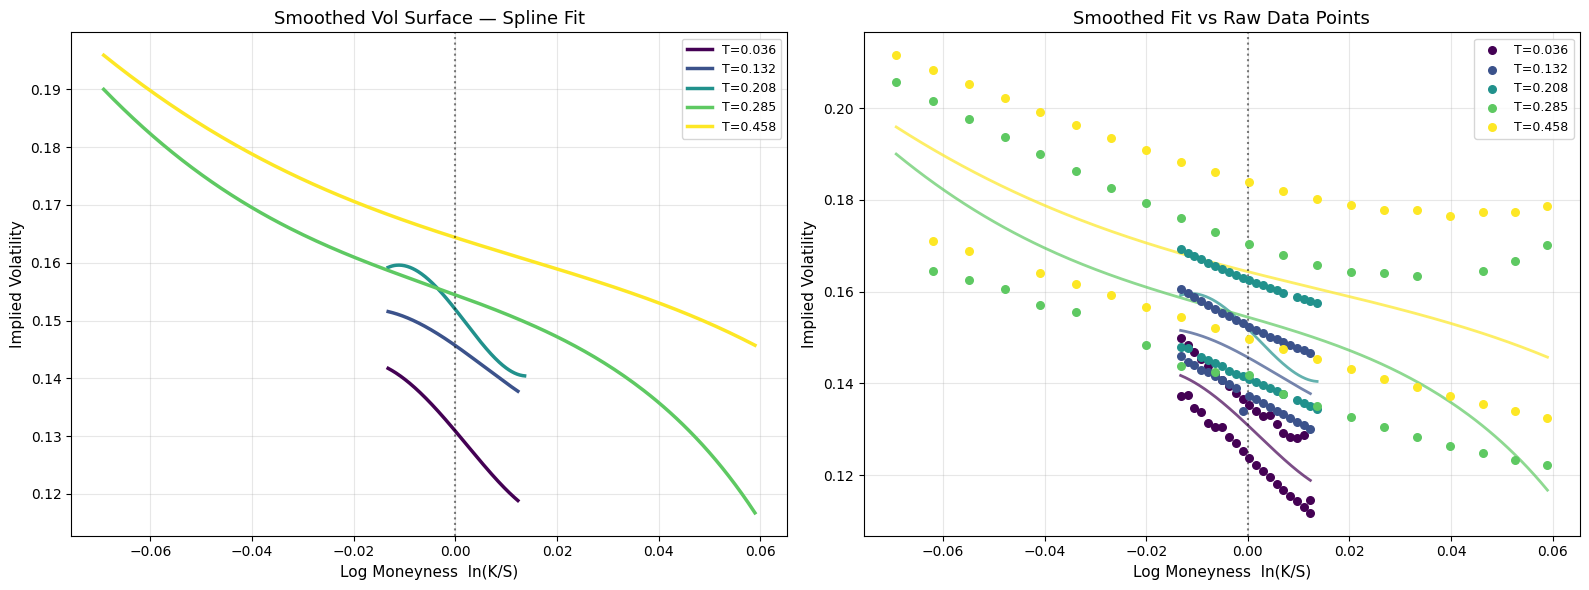

In [ ]:
# ============================================================
# WEEK 2 — FULL PIPELINE
# Cleaning, IV computation, surface construction, visualization
# ============================================================

from scipy.interpolate import CubicSpline
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---- REDEFINE BSM FUNCTIONS (session-safe) ----

def bsm_call_price(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bsm_put_price(S, K, T, r, sigma):
    call = bsm_call_price(S, K, T, r, sigma)
    return call - S + K * np.exp(-r * T)

def vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def implied_vol(market_price, S, K, T, r, option_type='call',
                initial_guess=0.20, max_iterations=100, tolerance=1e-6):
    sigma = initial_guess
    for i in range(max_iterations):
        price = bsm_call_price(S, K, T, r, sigma) if option_type == 'call' \
                else bsm_put_price(S, K, T, r, sigma)
        diff = price - market_price
        if abs(diff) < tolerance:
            return sigma
        v = vega(S, K, T, r, sigma)
        if v < 1e-8 or sigma <= 0 or sigma > 5:
            break
        sigma = sigma - diff / v
    try:
        objective = lambda s: (bsm_call_price(S, K, T, r, s) if option_type == 'call'
                               else bsm_put_price(S, K, T, r, s)) - market_price
        return brentq(objective, 1e-6, 5.0, xtol=tolerance)
    except:
        return np.nan

# ---- MARKET INPUTS ----

S = 744.78
r = 0.053
today = datetime.today()

# ---- SELECT ONE EXPIRY PER MONTH FOR A CLEAN SURFACE ----
# We pick the standard monthly expiry (third Friday of each month)
# plus one near-term weekly for the short end

target_expiries = [
    'Thu Jul 02 2026',   # very short dated — shows steep smile
    'Fri Jul 17 2026',   # ~2 weeks
    'Fri Aug 21 2026',   # ~7 weeks — standard monthly
    'Fri Sep 18 2026',   # ~11 weeks — standard monthly
    'Fri Oct 16 2026',   # ~15 weeks — standard monthly
    'Fri Dec 18 2026',   # ~24 weeks — standard monthly
]

df_filtered = df_raw[df_raw['Expiration Date'].isin(target_expiries)].copy()
print(f"Rows after expiry filter: {len(df_filtered)}")
print(df_filtered['Expiration Date'].value_counts().sort_index())

# ---- COMPUTE T ----

df_filtered['Expiry_dt'] = pd.to_datetime(df_filtered['Expiration Date'])
df_filtered['T'] = (df_filtered['Expiry_dt'] - today).dt.days / 365

# ---- SPLIT CALLS AND PUTS ----

calls = df_filtered[[
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Calls', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV', 'Delta', 'Gamma', 'Open Interest'
]].copy()
calls.columns = [
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Contract', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV_cboe', 'Delta_cboe', 'Gamma_cboe', 'Open Interest'
]
calls['option_type'] = 'call'

puts = df_filtered[[
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Puts', 'Last Sale.1', 'Net.1', 'Bid.1', 'Ask.1', 'Volume.1',
    'IV.1', 'Delta.1', 'Gamma.1', 'Open Interest.1'
]].copy()
puts.columns = [
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Contract', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV_cboe', 'Delta_cboe', 'Gamma_cboe', 'Open Interest'
]
puts['option_type'] = 'put'

options = pd.concat([calls, puts], ignore_index=True)
print(f"\nTotal options before cleaning: {len(options)}")

# ---- DATA CLEANING ----

options['Mid'] = (options['Bid'] + options['Ask']) / 2
options['Moneyness'] = options['Strike'] / S

n = len(options)
options = options[options['Volume'] > 0]
print(f"After zero volume filter:       {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['Open Interest'] > 10]
print(f"After low open interest filter: {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['Bid'] > 0]
print(f"After zero bid filter:          {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['T'] > 1/365]
print(f"After short dated filter:       {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[(options['Moneyness'] >= 0.85) & (options['Moneyness'] <= 1.15)]
print(f"After deep ITM/OTM filter:      {len(options)} (removed {n - len(options)})")

options = options.reset_index(drop=True)
print(f"\nFinal clean dataset: {len(options)} options")

# ---- COMPUTE IMPLIED VOL ----

def compute_iv_row(row):
    try:
        return implied_vol(row['Mid'], S, row['Strike'],
                          row['T'], r, row['option_type'])
    except:
        return np.nan

options['IV_computed'] = options.apply(compute_iv_row, axis=1)
options = options.dropna(subset=['IV_computed'])
options['log_moneyness'] = np.log(options['Strike'] / S)

print(f"IV computed for {len(options)} options")
print(f"\nOptions per expiry:")
print(options.groupby('Expiration Date')['IV_computed'].count())

# ---- PLOT 1: 2D SMILE SLICES ----

fig, ax = plt.subplots(figsize=(11, 6))

# Use one color per expiry, plot calls and puts together
expiry_list = options['Expiration Date'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(expiry_list)))

for i, expiry in enumerate(sorted(expiry_list)):
    slice_data = options[options['Expiration Date'] == expiry].sort_values('log_moneyness')
    ax.plot(slice_data['log_moneyness'], slice_data['IV_computed'],
            'o-', color=colors[i], label=expiry, linewidth=2, markersize=5)

ax.axvline(x=0, color='black', linestyle=':', alpha=0.5, label='ATM')
ax.set_xlabel('Log Moneyness  ln(K/S)', fontsize=12)
ax.set_ylabel('Implied Volatility', fontsize=12)
ax.set_title('SPY Volatility Smile by Expiry', fontsize=14)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- PLOT 2: 3D SURFACE ----

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(options['log_moneyness'], options['T'], options['IV_computed'],
           c=options['IV_computed'], cmap='viridis', s=60)

ax.set_xlabel('Log Moneyness')
ax.set_ylabel('Time to Expiry (years)')
ax.set_zlabel('Implied Vol')
ax.set_title('SPY Implied Volatility Surface — Raw Data')
plt.tight_layout()
plt.show()

from scipy.interpolate import UnivariateSpline

# ---- SMOOTHING SPLINE INTERPOLATION ----
# UnivariateSpline with smoothing factor s > 0 fits a smooth curve
# near the data rather than exactly through it — much better for
# noisy financial data with tightly packed strikes

print("Fitting smoothing splines...")
smooth_splines = {}

for expiry_T, group in options.groupby('T'):
    slice_data = group.sort_values('log_moneyness').drop_duplicates('log_moneyness')
    k_vals  = slice_data['log_moneyness'].values
    # Interpolate in total variance space
    w_vals  = (slice_data['IV_computed'].values ** 2) * expiry_T

    if len(k_vals) >= 4:
        # Apply more smoothing for wider strike ranges (longer dated expiries)
        # The wider the strike range, the more the spline needs to be constrained
        k_range = k_vals.max() - k_vals.min()
        if k_range > 0.05:
            s = len(k_vals) * (0.008 ** 2)  # heavy smoothing for wide range
        elif k_range > 0.02:
            s = len(k_vals) * (0.004 ** 2)  # medium smoothing
        else:
            s = len(k_vals) * (0.002 ** 2)  # light smoothing for narrow range
        try:
            spline = UnivariateSpline(k_vals, w_vals, s=s, k=3)
            smooth_splines[expiry_T] = {
                'spline': spline,
                'k_min': k_vals.min(),
                'k_max': k_vals.max()
            }
            print(f"  T={expiry_T:.3f} yrs — smoothing spline on {len(k_vals)} points")
        except Exception as e:
            print(f"  T={expiry_T:.3f} yrs — failed: {e}")

# ---- PLOT SMOOTHED SURFACE ----

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

expiry_ts_sorted = sorted(smooth_splines.keys())
colors = plt.cm.viridis(np.linspace(0, 1, len(expiry_ts_sorted)))

# Left plot: smoothed spline curves
ax = axes[0]
for i, T in enumerate(expiry_ts_sorted):
    kmin = smooth_splines[T]['k_min']
    kmax = smooth_splines[T]['k_max']
    k_plot = np.linspace(kmin, kmax, 200)

    w_plot = smooth_splines[T]['spline'](k_plot)
    # Convert total variance back to IV
    iv_plot = np.sqrt(np.maximum(w_plot, 1e-8) / T)

    ax.plot(k_plot, iv_plot, '-', color=colors[i],
            label=f'T={T:.3f}', linewidth=2.5)

ax.axvline(x=0, color='black', linestyle=':', alpha=0.5)
ax.set_xlabel('Log Moneyness  ln(K/S)', fontsize=11)
ax.set_ylabel('Implied Volatility', fontsize=11)
ax.set_title('Smoothed Vol Surface — Spline Fit', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right plot: raw data points overlaid for comparison
ax2 = axes[1]
for i, T in enumerate(expiry_ts_sorted):
    slice_data = options[options['T'].round(3) == round(T, 3)].sort_values('log_moneyness')
    ax2.scatter(slice_data['log_moneyness'], slice_data['IV_computed'],
                color=colors[i], s=30, label=f'T={T:.3f}', zorder=5)

    # Overlay the smooth fit
    kmin = smooth_splines[T]['k_min']
    kmax = smooth_splines[T]['k_max']
    k_plot = np.linspace(kmin, kmax, 200)
    w_plot = smooth_splines[T]['spline'](k_plot)
    iv_plot = np.sqrt(np.maximum(w_plot, 1e-8) / T)
    ax2.plot(k_plot, iv_plot, '-', color=colors[i], linewidth=2, alpha=0.7)

ax2.axvline(x=0, color='black', linestyle=':', alpha=0.5)
ax2.set_xlabel('Log Moneyness  ln(K/S)', fontsize=11)
ax2.set_ylabel('Implied Volatility', fontsize=11)
ax2.set_title('Smoothed Fit vs Raw Data Points', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- UPDATE VOL SURFACE CLASS TO USE SMOOTHING SPLINES ----

class VolSurface:
    def __init__(self, smooth_splines_dict, S):
        self.S = S
        self.smooth_splines = smooth_splines_dict
        self.expiry_ts = sorted(smooth_splines_dict.keys())

    def _query(self, T, k):
        k_min = self.smooth_splines[T]['k_min']
        k_max = self.smooth_splines[T]['k_max']
        k_clamped = np.clip(k, k_min, k_max)
        w = self.smooth_splines[T]['spline'](k_clamped)
        return max(float(w), 1e-8)

    def get_iv(self, K, T):
        k = np.log(K / self.S)
        ts = self.expiry_ts

        if T <= ts[0]:
            w = self._query(ts[0], k)